__Task_1__

- Аналитическое решение для задачи регресии: ω = inv(X.T @ X) @ X.T @ y
- Аналитическое решение для задачи регресии с добавлением регуляризации l2: ω = inv(X.T @ X + λI) @ X.T @ y
- Loss = ||Xω−y||​+λ * sum(​∣ωi​∣). В отличие от l2, которая плавно уменьшает веса, l1 имеет свойство обнулять многие веса.
- Применить нелинейное преобразование входных признаков.

__Task_2__

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
df_train = pd.read_json("train.json")

print(f"Shape of train dataset: {df_train.shape}")

Shape of train dataset: (49352, 15)


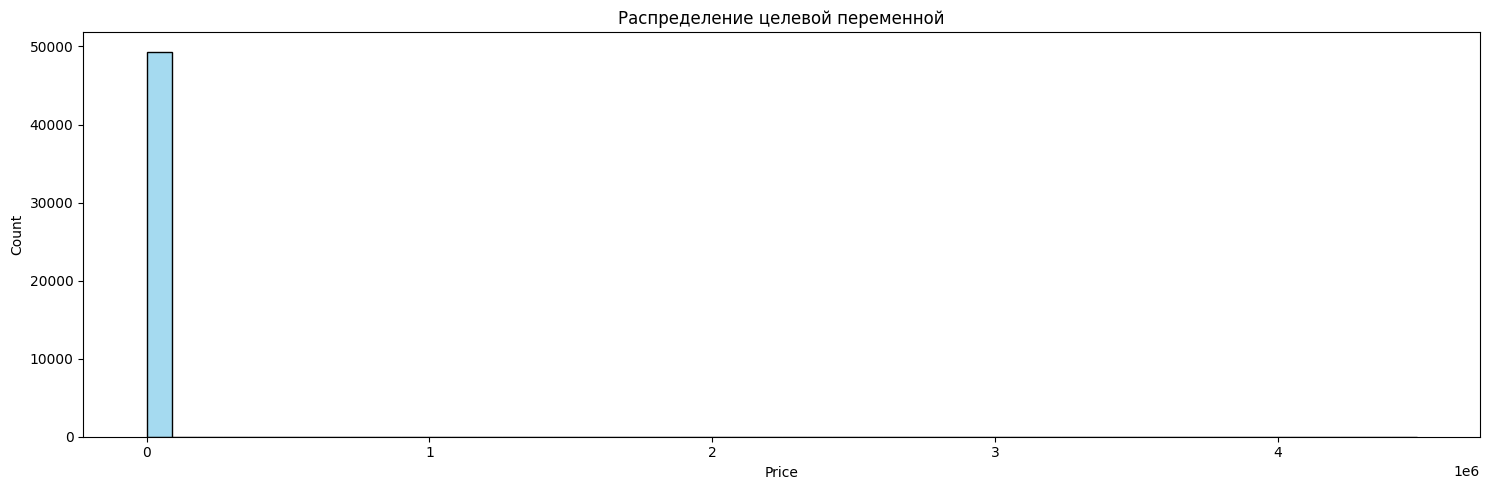

In [3]:
plt.figure(figsize=(15, 5))
sns.histplot(df_train['price'], bins=50, color="skyblue")
plt.title("Распределение целевой переменной")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [4]:
df_train = df_train[(df_train['price'] <= df_train['price'].quantile(0.99)) & (df_train['price'] >= df_train['price'].quantile(0.01))]

y_train = df_train['price']
X_train = df_train.drop('price', axis=1)

print(f"Shape of X_train dataset: {X_train.shape}")
print(f"Shape of y_train dataset: {y_train.shape}")

Shape of X_train dataset: (48379, 14)
Shape of y_train dataset: (48379,)


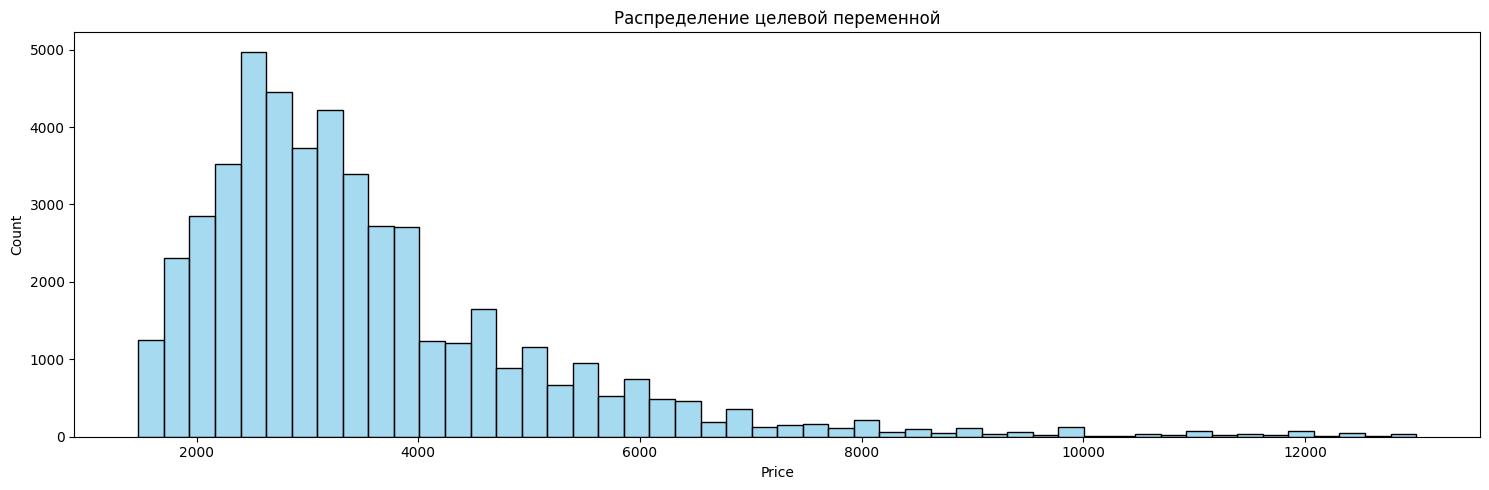

In [5]:
plt.figure(figsize=(15, 5))
sns.histplot(y_train, bins=50, color="skyblue")
plt.title("Распределение целевой переменной")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [6]:
labels = X_train["interest_level"]
encoder = LabelEncoder()
X_train["interest_level_encoded"] = encoder.fit_transform(labels)
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
X_train.drop('interest_level', axis=1, inplace=True)

__Task_3__

In [7]:
X_train["features_cleaned"] = X_train["features"].astype(str).str.replace(r"[\[\]'\" ]", '', regex=True)
X_train["features_list"] = X_train["features_cleaned"].str.split(',')

X_train.head(2)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,street_address,interest_level_encoded,features_cleaned,features_list
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,145 Borinquen Place,2,"DiningRoom,Pre-War,LaundryinBuilding,Dishwashe...","[DiningRoom, Pre-War, LaundryinBuilding, Dishw..."
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,230 East 44th,1,"Doorman,Elevator,LaundryinBuilding,Dishwasher,...","[Doorman, Elevator, LaundryinBuilding, Dishwas..."


In [8]:
all_features = []
for _, row in X_train.iterrows():
    if isinstance(row["features_list"], list):
        all_features.extend(row["features_list"])

feature_counts = Counter(all_features)

unique_features = set(all_features)
print(f"Уникальных признаков: {len(unique_features)}\n")

top_20 = feature_counts.most_common(20)
top_20_dict = dict(top_20)

for feature, count in top_20_dict.items():
    print(f"{feature}: {count}")

Уникальных признаков: 1530

Elevator: 25398
HardwoodFloors: 23159
CatsAllowed: 23148
DogsAllowed: 21662
Doorman: 20497
Dishwasher: 20095
NoFee: 17806
LaundryinBuilding: 16093
FitnessCenter: 13000
Pre-War: 8978
LaundryinUnit: 8448
RoofDeck: 6423
OutdoorSpace: 5137
DiningRoom: 4901
HighSpeedInternet: 4225
: 3109
Balcony: 2898
SwimmingPool: 2648
LaundryInBuilding: 2565
NewConstruction: 2507


In [9]:
top_20 = [f for f, _ in Counter(all_features).most_common(20)]

df_features_22 = X_train.copy()

for feature in top_20:
    df_features_22[feature] = df_features_22["features_list"].apply(
        lambda x: int(feature in x) if isinstance(x, list) else 0
    )

columns_to_keep = top_20 + ["bathrooms", "bedrooms"]
df_features_22 = df_features_22[columns_to_keep]

print(df_features_22.shape)

(48379, 22)


In [10]:
y_train.shape

(48379,)

__Task_4__

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

np.random.seed(21)

X_train, X_test, y_train, y_test = train_test_split(df_features_22, y_train, test_size=0.2, random_state=21)

print(f"Shape of X_train dataset: {X_train.shape}")
print(f"Shape of y_train dataset: {y_train.shape}")
print(f"Shape of X_test dataset: {X_test.shape}")
print(f"Shape of y_test dataset: {y_test.shape}")

Shape of X_train dataset: (38703, 22)
Shape of y_train dataset: (38703,)
Shape of X_test dataset: (9676, 22)
Shape of y_test dataset: (9676,)


In [12]:
class LinearRegressionSGD:
    def __init__(self, lr=0.01, n_iter=100):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = 0

    def fit(self, X, y):
        np.random.seed(21)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            for i in range(n_samples):
                xi = X.iloc[i].values
                yi = y.iloc[i] 
                y_pred = np.dot(xi, self.weights) + self.bias
                error = y_pred - yi

                self.weights -= self.lr * error * xi
                self.bias -= self.lr * error

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [13]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot

In [14]:
model_sgd = LinearRegressionSGD()
model_sgd.fit(X_train, y_train)

y_train_pred_sgd = model_sgd.predict(X_train)
y_test_pred_sgd = model_sgd.predict(X_test)

In [15]:
model_sk = LinearRegression()
model_sk.fit(X_train, y_train)

y_train_pred_sk = model_sk.predict(X_train)
y_test_pred_sk = model_sk.predict(X_test)

In [16]:
models = ["SGD", "sklearn"]

mae_table = pd.DataFrame({
    "model": models,
    "train": [
        mean_absolute_error(y_train, y_train_pred_sgd),
        mean_absolute_error(y_train, y_train_pred_sk),
    ],
    "test": [
        mean_absolute_error(y_test, y_test_pred_sgd),
        mean_absolute_error(y_test, y_test_pred_sk),
    ],
})

rmse_table = pd.DataFrame({
    "model": models,
    "train": [
        rmse(y_train, y_train_pred_sgd),
        rmse(y_train, y_train_pred_sk),
    ],
    "test": [
        rmse(y_test, y_test_pred_sgd),
        rmse(y_test, y_test_pred_sk),
    ],
})

r2_table = pd.DataFrame({
    "model": models,
    "train": [
        r2(y_train, y_train_pred_sgd),
        r2_score(y_train, y_train_pred_sk),
    ],
    "test": [
        r2(y_test, y_test_pred_sgd),
        r2_score(y_test, y_test_pred_sk),
    ],
})

In [17]:
mae_table.set_index('model')

,train,test
model,,
SGD,720.730932,715.503938
sklearn,712.818703,707.937466


In [18]:
rmse_table.set_index('model')

,train,test
model,,
SGD,1052.349638,1039.690913
sklearn,1037.569923,1025.377523


In [19]:
r2_table.set_index('model')

,train,test
model,,
SGD,0.566573,0.574762
sklearn,0.578662,0.586390


__Task_5__

In [20]:
class RidgeRegressionSGD:
    def __init__(self, lr=0.01, n_iter=100):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = 0

    def fit(self, X, y, alpha=1):
        np.random.seed(21)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            for i in range(n_samples):
                xi = X.iloc[i].values
                yi = y.iloc[i]
                y_pred = np.dot(xi, self.weights) + self.bias
                error = y_pred - yi

                self.weights -= self.lr * (error * xi + 2 * alpha * self.weights)
                self.bias -= self.lr * error

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [21]:
class LassoRegressionSGD:
    def __init__(self, lr=0.01, n_iter=100):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = 0

    def fit(self, X, y, alpha=1):
        np.random.seed(21)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            for i in range(n_samples):
                xi = X.iloc[i].values
                yi = y.iloc[i] 
                y_pred = np.dot(xi, self.weights) + self.bias
                error = y_pred - yi

                self.weights -= self.lr * (error * xi + alpha * np.sign(self.weights))
                self.bias -= self.lr * error

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [22]:
class ElasticNetRegressionSGD:
    def __init__(self, lr=0.01, n_iter=100):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = 0

    def fit(self, X, y, alpha=1, l1_ratio=0.5):
        np.random.seed(21)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            for i in range(n_samples):
                xi = X.iloc[i].values
                yi = y.iloc[i] 
                y_pred = np.dot(xi, self.weights) + self.bias
                error = y_pred - yi

                self.weights -= self.lr * (error * xi + alpha * (l1_ratio * np.sign(self.weights) + 2 * (1 - l1_ratio) * self.weights))
                self.bias -= self.lr * error

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [23]:
model_ridge_sgd = RidgeRegressionSGD()
model_ridge_sgd.fit(X_train, y_train)

y_train_ridge_pred_sgd = model_sgd.predict(X_train)
y_test_ridge_pred_sgd = model_sgd.predict(X_test)

model_lasso_sgd = LassoRegressionSGD()
model_lasso_sgd.fit(X_train, y_train)

y_train_lasso_pred_sgd = model_sgd.predict(X_train)
y_test_lasso_pred_sgd = model_sgd.predict(X_test)

model_elasticnet_sgd = ElasticNetRegressionSGD()
model_elasticnet_sgd.fit(X_train, y_train)

y_train_elasticnet_pred_sgd = model_sgd.predict(X_train)
y_test_elasticnet_pred_sgd = model_sgd.predict(X_test)

In [24]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

model_ridge_sk = Ridge()
model_ridge_sk.fit(X_train, y_train)

y_train_ridge_pred_sk = model_ridge_sk.predict(X_train)
y_test_ridge_pred_sk = model_ridge_sk.predict(X_test)

model_lasso_sk = Lasso()
model_lasso_sk.fit(X_train, y_train)

y_train_lasso_pred_sk = model_lasso_sk.predict(X_train)
y_test_lasso_pred_sk = model_lasso_sk.predict(X_test)

model_elasticnet_sk = ElasticNet()
model_elasticnet_sk.fit(X_train, y_train)

y_train_elasticnet_pred_sk = model_elasticnet_sk.predict(X_train)
y_test_elasticnet_pred_sk = model_elasticnet_sk.predict(X_test)

In [25]:
models = ["RidgeRegressionSGD", "RidgeRegressionSklearn", "LassoRegressionSGD", "LassoRegressionSklearn", "ElasticNetRegressionSGD", "ElasticNetRegressionSklearn"]

mae_table = pd.DataFrame({
    "model": models,
    "train": [
        mean_absolute_error(y_train, y_train_ridge_pred_sgd),
        mean_absolute_error(y_train, y_train_ridge_pred_sk),
        mean_absolute_error(y_train, y_train_lasso_pred_sgd),
        mean_absolute_error(y_train, y_train_lasso_pred_sk),
        mean_absolute_error(y_train, y_train_elasticnet_pred_sgd),
        mean_absolute_error(y_train, y_train_elasticnet_pred_sk),
    ],
    "test": [
        mean_absolute_error(y_test, y_test_ridge_pred_sgd),
        mean_absolute_error(y_test, y_test_ridge_pred_sk),
        mean_absolute_error(y_test, y_test_lasso_pred_sgd),
        mean_absolute_error(y_test, y_test_lasso_pred_sk),
        mean_absolute_error(y_test, y_test_elasticnet_pred_sgd),
        mean_absolute_error(y_test, y_test_elasticnet_pred_sk),
    ],
})

rmse_table = pd.DataFrame({
    "model": models,
    "train": [
        rmse(y_train, y_train_ridge_pred_sgd),
        rmse(y_train, y_train_ridge_pred_sk),
        rmse(y_train, y_train_lasso_pred_sgd),
        rmse(y_train, y_train_lasso_pred_sk),
        rmse(y_train, y_train_elasticnet_pred_sgd),
        rmse(y_train, y_train_elasticnet_pred_sk),
    ],
    "test": [
        rmse(y_test, y_test_ridge_pred_sgd),
        rmse(y_test, y_test_ridge_pred_sk),
        rmse(y_test, y_test_lasso_pred_sgd),
        rmse(y_test, y_test_lasso_pred_sk),
        rmse(y_test, y_test_elasticnet_pred_sgd),
        rmse(y_test, y_test_elasticnet_pred_sk),
    ],
})

r2_table = pd.DataFrame({
    "model": models,
    "train": [
        r2(y_train, y_train_ridge_pred_sgd),
        r2_score(y_train, y_train_ridge_pred_sk),
        r2(y_train, y_train_lasso_pred_sgd),
        r2_score(y_train, y_train_lasso_pred_sk),
        r2(y_train, y_train_elasticnet_pred_sgd),
        r2_score(y_train, y_train_elasticnet_pred_sk),
    ],
    "test": [
        r2(y_test, y_test_ridge_pred_sgd),
        r2_score(y_test, y_test_ridge_pred_sk),
        r2(y_test, y_test_lasso_pred_sgd),
        r2_score(y_test, y_test_lasso_pred_sk),
        r2(y_test, y_test_elasticnet_pred_sgd),
        r2_score(y_test, y_test_elasticnet_pred_sk),
    ],
})

In [26]:
mae_table.set_index('model')

,train,test
model,,
RidgeRegressionSGD,720.730932,715.503938
RidgeRegressionSklearn,712.815210,707.930383
LassoRegressionSGD,720.730932,715.503938
LassoRegressionSklearn,712.500365,707.507528
ElasticNetRegressionSGD,720.730932,715.503938
ElasticNetRegressionSklearn,809.798305,796.049016


In [27]:
rmse_table.set_index('model')

,train,test
model,,
RidgeRegressionSGD,1052.349638,1039.690913
RidgeRegressionSklearn,1037.569931,1025.374498
LassoRegressionSGD,1052.349638,1039.690913
LassoRegressionSklearn,1037.738727,1025.205105
ElasticNetRegressionSGD,1052.349638,1039.690913
ElasticNetRegressionSklearn,1193.273218,1176.876620


In [28]:
r2_table.set_index('model')

,train,test
model,,
RidgeRegressionSGD,0.566573,0.574762
RidgeRegressionSklearn,0.578662,0.586392
LassoRegressionSGD,0.566573,0.574762
LassoRegressionSklearn,0.578525,0.586529
ElasticNetRegressionSGD,0.566573,0.574762
ElasticNetRegressionSklearn,0.442717,0.455139


__Task_6__

Модели, чувствительные к масштабу данных:
- KNN, KMeans, SVM, LogReg, GradientDescent-models
Эти алгоритмы используют расстояния или градиенты, и если признаки на разных масштабах это искажает обучение.
- PCA
Работает на основе дисперсий, и несбалансированные признаки могут исказить главные компоненты.

Когда нормализация не обязательна или даже вредна:
- DecisionTree, RandomForest, XGBoost, CatBoost, LightGBM
Эти модели не используют расстояния или градиенты по признакам, поэтому масштаб признаков им не важен.

Математическая формула для MinMaxScaler:

X_scaled ​= (X ​− X_min) / (​X_max − X_min​​)

In [29]:
class CustomMinMaxScaler:
    def __init__(self, feature_range=(0, 1)):
        self.min = None
        self.max = None
        self.feature_range = feature_range

    def fit(self, X):
        self.min = X.min()
        self.max = X.max()

    def transform(self, X):
        X = X.copy()
        X_scaled = (X - self.min) / (self.max - self.min)
        X_scaled = X_scaled * (self.feature_range[1] - self.feature_range[0]) + self.feature_range[0]
        return X_scaled

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [30]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = pd.DataFrame({
    'feature_1': [10, 20, 30, 40, 50],
    'feature_2': [100, 80, 60, 40, 20]
})

custom_scaler = CustomMinMaxScaler()
custom_scaled = custom_scaler.fit_transform(df)

sk_scaler = MinMaxScaler()
sklearn_scaled = sk_scaler.fit_transform(df)
sklearn_scaled_df = pd.DataFrame(sklearn_scaled, columns=df.columns)

print("Custom MinMaxScaler:")
print(custom_scaled.round(4))

print("\nSklearn MinMaxScaler:")
print(sklearn_scaled_df.round(4))

print("\nРазница:")
print((custom_scaled - sklearn_scaled_df).abs().round(8))

Custom MinMaxScaler:
   feature_1  feature_2
0       0.00       1.00
1       0.25       0.75
2       0.50       0.50
3       0.75       0.25
4       1.00       0.00

Sklearn MinMaxScaler:
   feature_1  feature_2
0       0.00       1.00
1       0.25       0.75
2       0.50       0.50
3       0.75       0.25
4       1.00       0.00

Разница:
   feature_1  feature_2
0        0.0        0.0
1        0.0        0.0
2        0.0        0.0
3        0.0        0.0
4        0.0        0.0


Математическая формула для StandardScaler:

X_scaled ​= (X ​− μ) / σ

In [31]:
class CustomStandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        self.mean = X.mean()
        self.std = X.std(ddof=0)

    def transform(self, X):
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [32]:
df = pd.DataFrame({
    'feature_1': [10, 20, 30, 40, 50],
    'feature_2': [100, 80, 60, 40, 20]
})

custom_scaler = CustomStandardScaler()
custom_scaled = custom_scaler.fit_transform(df)

sk_scaler = StandardScaler()
sklearn_scaled = sk_scaler.fit_transform(df)
sklearn_scaled_df = pd.DataFrame(sklearn_scaled, columns=df.columns)

print("Custom StandardScaler:")
print(custom_scaled.round(4))

print("\nSklearn StandardScaler:")
print(sklearn_scaled_df.round(4))

print("\nРазница:")
print((custom_scaled - sklearn_scaled_df).abs().round(8))

Custom StandardScaler:
   feature_1  feature_2
0    -1.4142     1.4142
1    -0.7071     0.7071
2     0.0000     0.0000
3     0.7071    -0.7071
4     1.4142    -1.4142

Sklearn StandardScaler:
   feature_1  feature_2
0    -1.4142     1.4142
1    -0.7071     0.7071
2     0.0000     0.0000
3     0.7071    -0.7071
4     1.4142    -1.4142

Разница:
   feature_1  feature_2
0        0.0        0.0
1        0.0        0.0
2        0.0        0.0
3        0.0        0.0
4        0.0        0.0


__Task_7__

In [33]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results = {
        "mae_train": mean_absolute_error(y_train, y_train_pred),
        "mae_test": mean_absolute_error(y_test, y_test_pred),
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "rmse_test": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "r2_train": r2_score(y_train, y_train_pred),
        "r2_test": r2_score(y_test, y_test_pred),
    }
    return results

In [34]:
scalers = {
    "default": None,
    "MinMax": MinMaxScaler(),
    "Standard": StandardScaler(),
}

models = {
    "LinReg": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
}

results = []

for scale_name, scaler in scalers.items():
    if scaler is not None:
        scaler.fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()

    for model_name, model in models.items():
        metrics = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)
        results.append({
            "model": f"{model_name} {scale_name}",
            "mae_train": metrics["mae_train"],
            "mae_test": metrics["mae_test"],
            "rmse_train": metrics["rmse_train"],
            "rmse_test": metrics["rmse_test"],
            "r2_train": metrics["r2_train"],
            "r2_test": metrics["r2_test"],
        })


In [35]:
metrics_df = pd.DataFrame(results)
metrics_df.set_index("model", inplace=True)

result_mae = metrics_df[["mae_train", "mae_test"]]
result_rmse = metrics_df[["rmse_train", "rmse_test"]]
result_r2 = metrics_df[["r2_train", "r2_test"]]


In [36]:
result_mae

,mae_train,mae_test
model,,
LinReg default,712.818703,707.937466
Ridge default,712.815210,707.930383
Lasso default,712.774622,707.879083
ElasticNet default,717.981908,709.205755
LinReg MinMax,712.818703,707.937466
Ridge MinMax,712.963576,707.911440
Lasso MinMax,712.802908,707.864602
ElasticNet MinMax,926.258322,921.534296
LinReg Standard,712.818703,707.937466


In [37]:
result_rmse

,rmse_train,rmse_test
model,,
LinReg default,1037.569923,1025.377523
Ridge default,1037.569931,1025.374498
Lasso default,1037.571725,1025.345676
ElasticNet default,1052.029264,1036.542742
LinReg MinMax,1037.569923,1025.377523
Ridge MinMax,1037.620575,1025.441442
Lasso MinMax,1037.573978,1025.347742
ElasticNet MinMax,1334.130713,1332.398199
LinReg Standard,1037.569923,1025.377523


In [38]:
result_r2

,r2_train,r2_test
model,,
LinReg default,0.578662,0.586390
Ridge default,0.578662,0.586392
Lasso default,0.578660,0.586415
ElasticNet default,0.566837,0.577333
LinReg MinMax,0.578662,0.586390
Ridge MinMax,0.578621,0.586338
Lasso MinMax,0.578658,0.586414
ElasticNet MinMax,0.303385,0.301620
LinReg Standard,0.578662,0.586390


__Task_8__

In [39]:
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder

base_features = ['bathrooms', 'bedrooms', 'interest_level']

df_copy = df_train.copy()
le = LabelEncoder()
df_copy['interest_level'] = le.fit_transform(df_copy['interest_level'])

X = df_copy[base_features]
y = df_copy['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [40]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1, max_iter=1000),
    "ElasticNet (alpha=0.1)": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=1000),
}

results = []

for name, model in models.items():
    model.fit(X_poly_train, y_train)
    y_train_pred = model.predict(X_poly_train)
    y_test_pred = model.predict(X_poly_test)

    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    results.append({
        "model": name,
        "mae_train": mae_train,
        "mae_test": mae_test,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "r2_train": r2_train,
        "r2_test": r2_test,
    })

/home/daisymal/ML.Project_2.ID_1254799-1/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.100e+10, tolerance: 9.889e+06
  model = cd_fast.enet_coordinate_descent(
/home/daisymal/ML.Project_2.ID_1254799-1/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.119e+10, tolerance: 9.889e+06
  model = cd_fast.enet_coordinate_descent(


In [41]:
metrics_df = pd.DataFrame(results)
metrics_df.set_index('model')

,mae_train,mae_test,rmse_train,rmse_test,r2_train,r2_test
model,,,,,,
LinearRegression,722.350049,877.828148,1032.291563,12223.075286,0.582938,-57.773929
Ridge (alpha=1.0),722.489620,749.370829,1032.523382,2637.587694,0.582750,-1.736765
Lasso (alpha=0.1),728.178162,726.903706,1041.218829,1042.324579,0.575693,0.572605
ElasticNet (alpha=0.1),729.249844,726.938734,1043.355604,1043.239477,0.573950,0.571854


__Task_9__

In [42]:
final_result = result_mae.merge(result_rmse, on='model').merge(result_r2, on='model')

In [43]:
final_result.loc['Mean'] = final_result.mean()
final_result.loc['Median'] = final_result.median()
final_result = final_result.round(3)

__Task_10__

In [44]:
final_result

,mae_train,mae_test,rmse_train,rmse_test,r2_train,r2_test
model,,,,,,
LinReg default,712.819,707.937,1037.570,1025.378,0.579,0.586
Ridge default,712.815,707.930,1037.570,1025.374,0.579,0.586
Lasso default,712.775,707.879,1037.572,1025.346,0.579,0.586
ElasticNet default,717.982,709.206,1052.029,1036.543,0.567,0.577
LinReg MinMax,712.819,707.937,1037.570,1025.378,0.579,0.586
Ridge MinMax,712.964,707.911,1037.621,1025.441,0.579,0.586
Lasso MinMax,712.803,707.865,1037.574,1025.348,0.579,0.586
ElasticNet MinMax,926.258,921.534,1334.131,1332.398,0.303,0.302
LinReg Standard,712.819,707.937,1037.570,1025.378,0.579,0.586


In [45]:
df_diff = pd.DataFrame(index=final_result.index)

df_diff['mae_diff'] = final_result['mae_train'] - final_result['mae_test']
df_diff['rmse_diff'] = final_result['rmse_train'] - final_result['rmse_test']
df_diff['r2_diff'] = final_result['r2_train'] - final_result['r2_test']

df_diff = df_diff.drop(['Mean', 'Median'], errors='ignore')
df_diff = df_diff.round(3)

df_diff

,mae_diff,rmse_diff,r2_diff
model,,,
LinReg default,4.882,12.192,-0.007
Ridge default,4.885,12.196,-0.007
Lasso default,4.896,12.226,-0.007
ElasticNet default,8.776,15.486,-0.010
LinReg MinMax,4.882,12.192,-0.007
Ridge MinMax,5.053,12.180,-0.007
Lasso MinMax,4.938,12.226,-0.007
ElasticNet MinMax,4.724,1.733,0.001
LinReg Standard,4.882,12.192,-0.007


Лучшей моделью по метрикам mae, rmse, r2: Lasso MinMax

По стабильности лучший результат показала модель ElasticNet MinMax, разброс на тестовой выборке получается всего 0.001.

__Task_11__

In [46]:
from sklearn.pipeline import make_pipeline

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

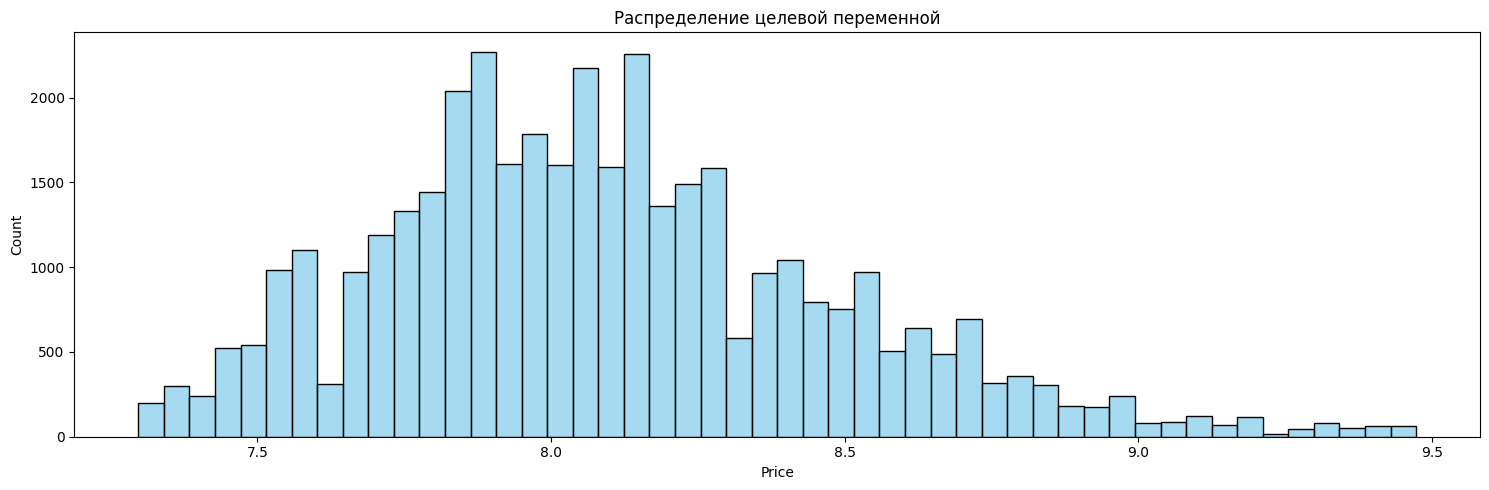

In [47]:
plt.figure(figsize=(15, 5))
sns.histplot(y_train_log, bins=50, color="skyblue")
plt.title("Распределение целевой переменной")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [48]:
model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

In [49]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")

MAE: 772.17
RMSE: 1136.05
R2: 0.492


In [50]:
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (y_train >= lower_bound) & (y_train <= upper_bound)

X_train_filtered = X_train[mask]
y_train_filtered = y_train[mask]

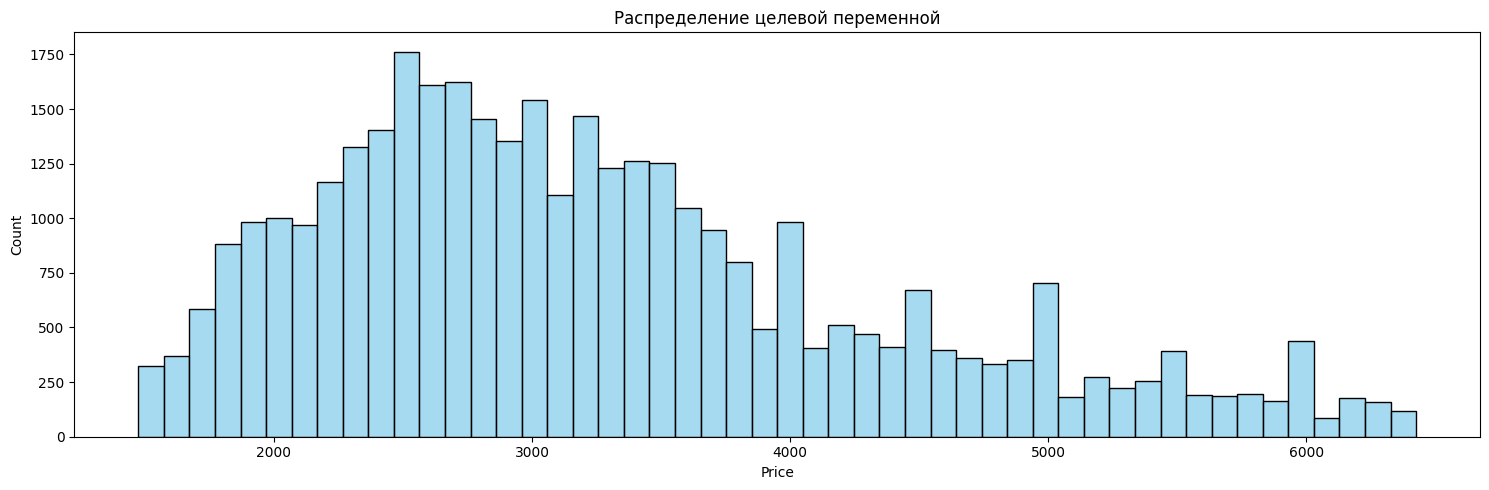

In [51]:
plt.figure(figsize=(15, 5))
sns.histplot(y_train_filtered, bins=50, color="skyblue")
plt.title("Распределение целевой переменной")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [52]:
model = LinearRegression()
model.fit(X_train_filtered, y_train_filtered)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
y_pred = model.predict(X_test)

In [54]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")

MAE: 793.26
RMSE: 1043.36
R2: 0.448


In [ ]:
class LinearRegressionMiniBatch:
    def __init__(self, learning_rate=0.01, n_iters=1000, batch_size=32):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.batch_size = batch_size
        self.theta = None

    def fit(self, X, y):
        X = np.c_[np.ones(X.shape[0]), X]
        m, n = X.shape
        self.theta = np.zeros(n)

        for i in range(self.n_iters):
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for start in range(0, m, self.batch_size):
                end = start + self.batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                gradient = X_batch.T @ (X_batch @ self.theta - y_batch) / X_batch.shape[0]
                self.theta -= self.lr * gradient

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]
        return X @ self.theta